# warp_from_dots — how the 2.4um → 7.91um alignment works

The scroll4 w023 sheet was scanned at two densities that were flattened **differently**, so the
2.4um frame (where ink is visible → our label source) does **not** line up pixel-for-pixel with
the 7.91um frame (the modality we train on / that scroll3 shares). To move the 2.4um ink labels
into the 7.91um frame we fit a **thin-plate spline (TPS)** through a handful of hand-marked
corresponding points.

This notebook demonstrates the whole idea on the two locally-committed marked images:

- `warp_MARK_2p4_source_dots.png` — the 2.4um SOURCE, with colored anchor dots
- `warp_MARK_7p9_target_dots.png` — the 7.91um (flipped) TARGET, same colors on the same features

Each correspondence is marked with the **same palette color** in both images. The steps below
reuse the exact detection/matching functions from `warp_from_dots.py` so the demo stays in sync
with the real tool.

source (655, 1600, 3)   target (672, 1600, 3)


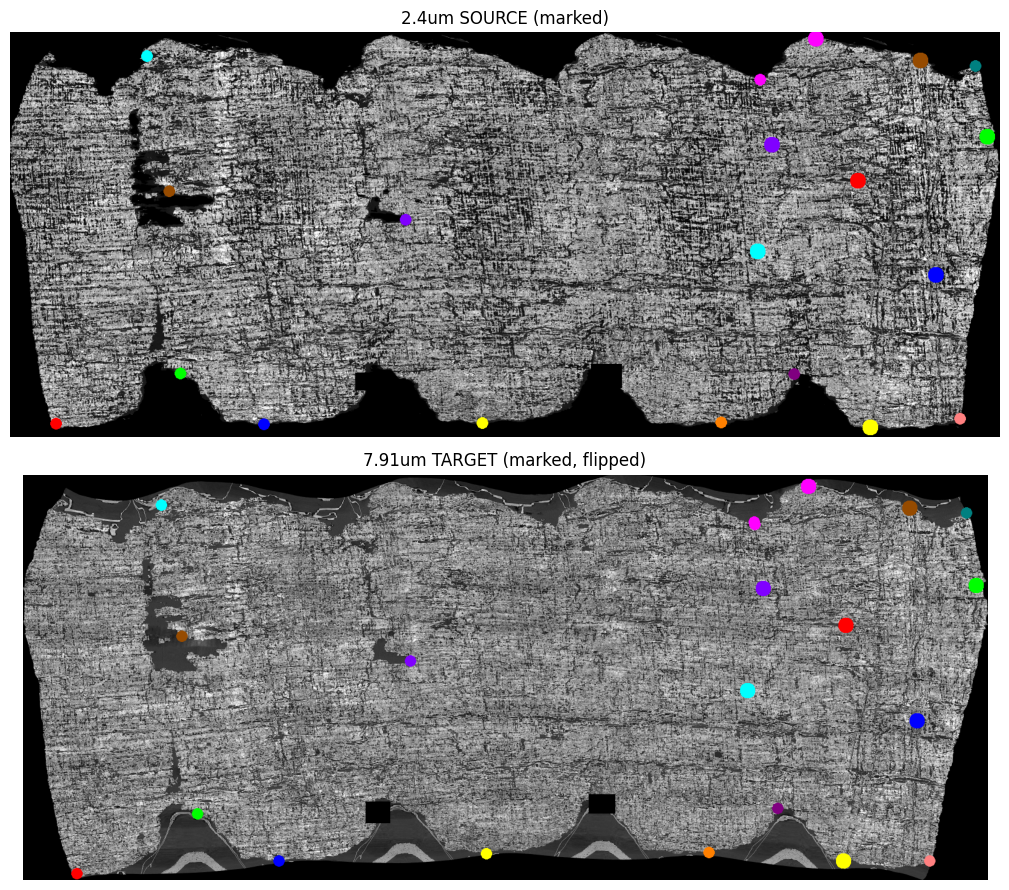

In [16]:
import os
import importlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator

# reuse the REAL detection + matching logic from the tool.
# reload so edits to warp_from_dots.py (e.g. the doubled-anchor matching) are always picked up.
import warp_from_dots as wfd
importlib.reload(wfd)

SRC = 'warp_MARK_2p4_source_dots.png'   # 2.4um source (has ink labels)
DST = 'warp_MARK_7p9_target_dots.png'   # 7.91um target (flipped)

src_bgr = cv2.imread(SRC, cv2.IMREAD_COLOR)
dst_bgr = cv2.imread(DST, cv2.IMREAD_COLOR)
print('source', src_bgr.shape, '  target', dst_bgr.shape)

fig, ax = plt.subplots(2, 1, figsize=(16, 9))
ax[0].imshow(cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)); ax[0].set_title('2.4um SOURCE (marked)'); ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(dst_bgr, cv2.COLOR_BGR2RGB)); ax[1].set_title('7.91um TARGET (marked, flipped)'); ax[1].axis('off')
plt.tight_layout(); plt.show()


## 1. Detect the colored dots

A pixel counts as a marker if it is **saturated** (the underlying sheet is grayscale, so any
colored pixel is a user dot). Connected blobs are found, and each blob's mean color is snapped to
the nearest entry in a 12-color reference palette (`red, green, blue, …`). This snapping is what
lets us pair a dot in the source with its twin in the target purely by color name.

detected  source=20  target=20 dots


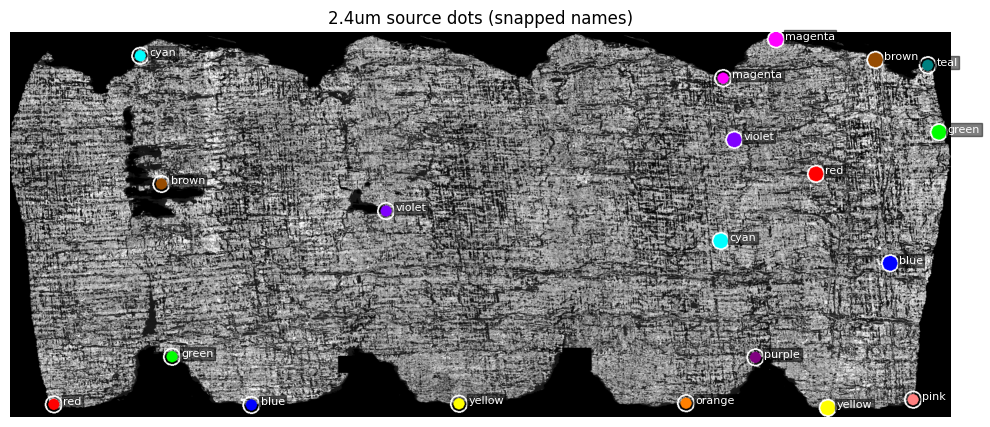

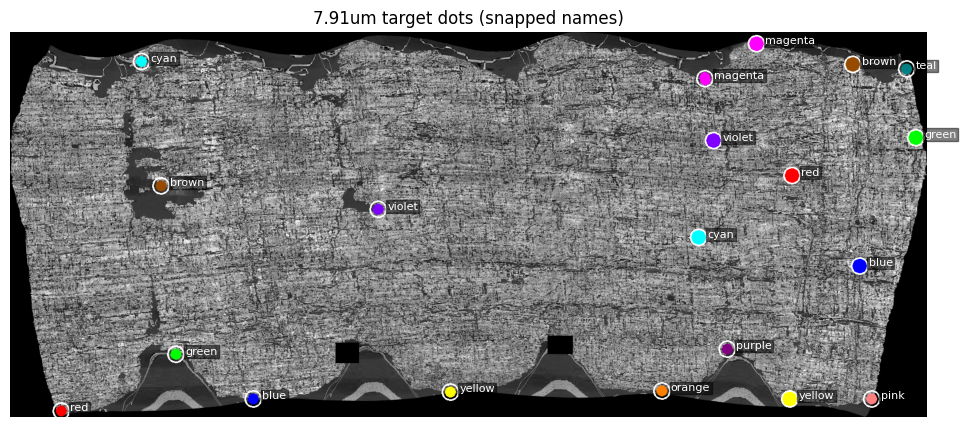

In [17]:
src_dots, (sh, sw) = wfd.detect_dots(SRC)
dst_dots, (dh, dw) = wfd.detect_dots(DST)
print(f'detected  source={len(src_dots)}  target={len(dst_dots)} dots')

def show_dots(bgr, dots, title):
    im = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).copy()
    for name, x, y, area, dist in dots:
        cv2.circle(im, (int(x), int(y)), 14, (255, 255, 255), 2)
    plt.imshow(im); plt.title(title); plt.axis('off')
    for name, x, y, area, dist in dots:
        plt.text(x + 16, y, name, color='white', fontsize=8,
                 bbox=dict(facecolor='black', alpha=0.5, pad=1))

plt.figure(figsize=(16, 5)); show_dots(src_bgr, src_dots, '2.4um source dots (snapped names)'); plt.show()
plt.figure(figsize=(16, 5)); show_dots(dst_bgr, dst_dots, '7.91um target dots (snapped names)'); plt.show()

## 2. Match source ↔ target by color

Dots that snap to the same palette name are paired. **Anchor tripling:** a color may be used
**up to 3× per image** (36 anchors from the 12-color palette). When a color appears multiple
times, dots pair by **x-order** — leftmost↔leftmost, … rightmost↔rightmost, labelled `.1/.2/.3`
left→right — safe because the warp is mild and preserves left→right order. A color used once
pairs directly (bare name).

The plot below labels every dot with its resolved name (incl. `.1/.2/.3`) and draws a line for
each correspondence, so you can **visually confirm** each line connects the right two features
and that no ordering got swapped.


20 color-matched pairs (up to 3 per palette color, x-ordered .1/.2/.3):
   blue.1      src(   410,   634) -> dst(   424,   640)
   blue.2      src(  1496,   393) -> dst(  1482,   408)
   brown.1     src(   257,   258) -> dst(   263,   268)
   brown.2     src(  1471,    47) -> dst(  1470,    56)
   cyan.1      src(   221,    40) -> dst(   229,    51)
   cyan.2      src(  1208,   355) -> dst(  1201,   358)
   green.1     src(   275,   552) -> dst(   289,   562)
   green.2     src(  1579,   170) -> dst(  1580,   184)
   magenta.1   src(  1212,    78) -> dst(  1212,    81)
   magenta.2   src(  1302,    12) -> dst(  1302,    20)
   orange      src(  1149,   631) -> dst(  1137,   626)
   pink        src(  1535,   625) -> dst(  1503,   640)
   purple      src(  1267,   553) -> dst(  1251,   553)
   red.1       src(    74,   633) -> dst(    89,   661)
   red.2       src(  1370,   241) -> dst(  1364,   250)
   teal        src(  1560,    56) -> dst(  1564,    64)
   violet.1    src(   639,   304

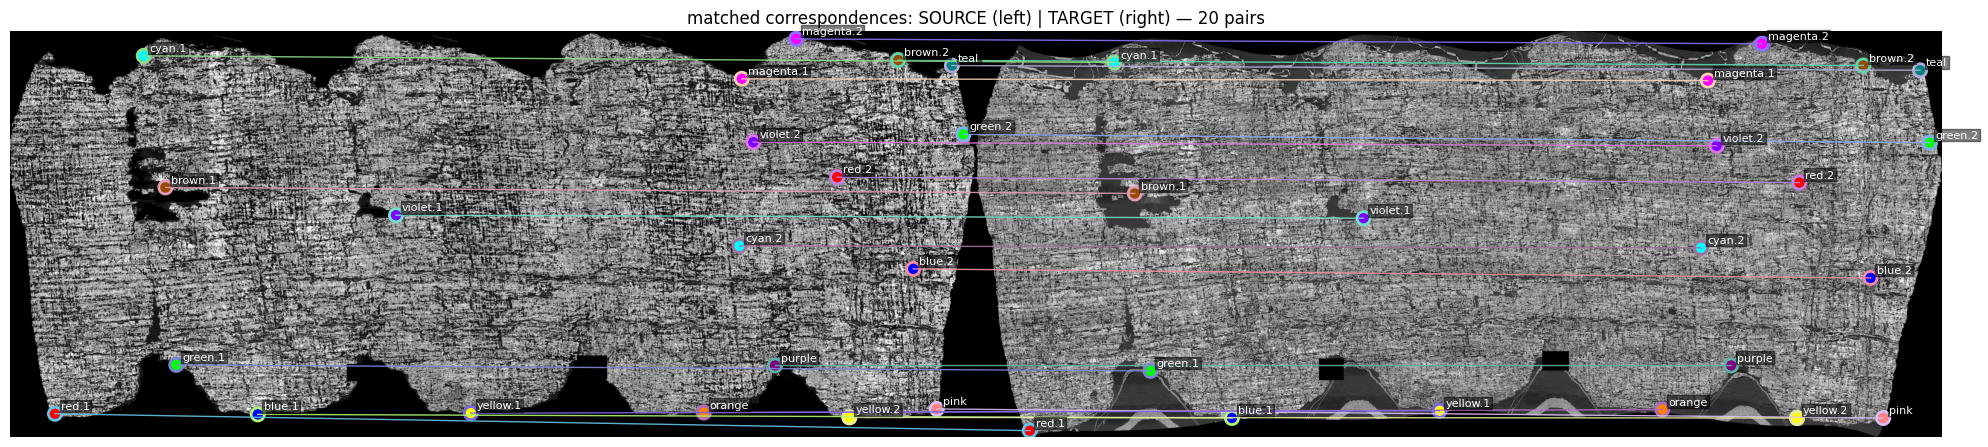

In [18]:
pairs = wfd.match_by_color(src_dots, dst_dots)
print(f'{len(pairs)} color-matched pairs (up to 3 per palette color, x-ordered .1/.2/.3):')
for xs, ys, xd, yd, name in pairs:
    print(f'   {name:11s} src({xs:6.0f},{ys:6.0f}) -> dst({xd:6.0f},{yd:6.0f})')

# side-by-side canvas with labelled dots + connecting lines so mismatches are obvious
H = max(sh, dh)
canvas = np.zeros((H, sw + dw, 3), np.uint8)
canvas[:sh, :sw] = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)
canvas[:dh, sw:] = cv2.cvtColor(dst_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 9)); plt.imshow(canvas); plt.axis('off')
plt.title(f'matched correspondences: SOURCE (left) | TARGET (right) — {len(pairs)} pairs')
rng = np.random.default_rng(1)
for xs, ys, xd, yd, name in pairs:
    col = rng.uniform(0.35, 1.0, 3)                 # distinct color per correspondence
    # source dot (left) + target dot (right, x-shifted onto the joined canvas)
    plt.scatter([xs, xd + sw], [ys, yd], s=90, facecolors='none', edgecolors=[col], linewidths=2)
    plt.plot([xs, xd + sw], [ys, yd], '-', color=col, linewidth=1.0, alpha=0.9)
    # label both ends with the resolved name (incl .1/.2/.3) so swaps are visible
    for lx, ly in ((xs, ys), (xd + sw, yd)):
        plt.text(lx + 10, ly - 8, name, color='white', fontsize=8,
                 bbox=dict(facecolor='black', alpha=0.5, pad=1))
plt.tight_layout(); plt.show()


## 3. Fit the thin-plate spline and build the remap grid

We fit TPS mapping **target → source** for x and y separately (that direction is what `cv2.remap`
needs: for every output/target pixel, where in the source do we sample?). Image corners are added
as anchors so the edges stay stable. Evaluating the spline over the full target grid yields the
`mapx` / `mapy` sampling coordinates.

> Note: OpenCV's `createThinPlateSplineShapeTransformer` isn't available in this build, so we use
> scipy's `RBFInterpolator(kernel='thin_plate_spline')` — the same approach the tool uses.

map shape (672, 1600)  (target frame)


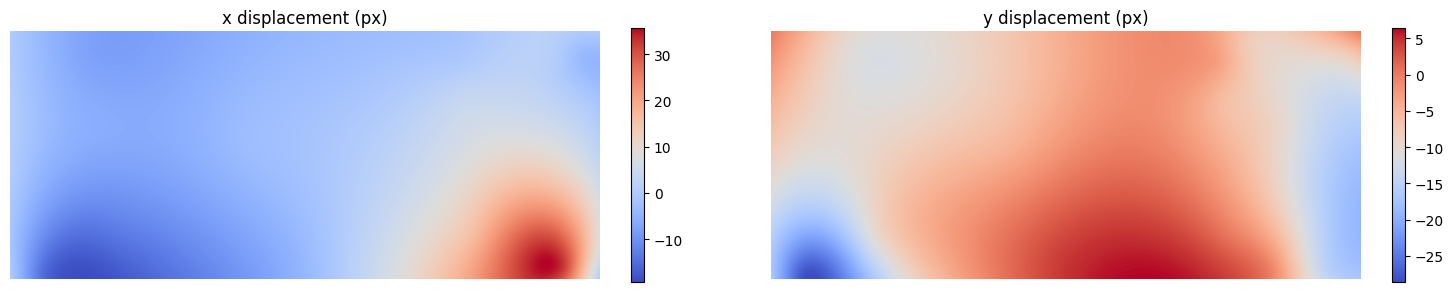

In [19]:
assert len(pairs) >= 3, 'need >= 3 matched dots for a stable warp'

# work at the target image resolution for this demo
src_pts = np.array([[xs, ys] for xs, ys, xd, yd, _ in pairs], float)
dst_pts = np.array([[xd, yd] for xs, ys, xd, yd, _ in pairs], float)
# corner anchors (target corners -> source corners) for edge stability
corners_dst = [[0, 0], [dw - 1, 0], [0, dh - 1], [dw - 1, dh - 1]]
corners_src = [[0, 0], [sw - 1, 0], [0, sh - 1], [sw - 1, sh - 1]]
dst_pts = np.vstack([dst_pts, corners_dst])
src_pts = np.vstack([src_pts, corners_src])

fx = RBFInterpolator(dst_pts, src_pts[:, 0], kernel='thin_plate_spline', smoothing=1.0)
fy = RBFInterpolator(dst_pts, src_pts[:, 1], kernel='thin_plate_spline', smoothing=1.0)
gy, gx = np.mgrid[0:dh, 0:dw]
grid = np.column_stack([gx.ravel(), gy.ravel()]).astype(float)
mapx = fx(grid).reshape(dh, dw).astype(np.float32)
mapy = fy(grid).reshape(dh, dw).astype(np.float32)
print('map shape', mapx.shape, ' (target frame)')

# visualize the displacement the warp applies (target->source offsets)
dispx = mapx - gx; dispy = mapy - gy
fig, ax = plt.subplots(1, 2, figsize=(18, 4))
im0 = ax[0].imshow(dispx, cmap='coolwarm'); ax[0].set_title('x displacement (px)'); ax[0].axis('off'); fig.colorbar(im0, ax=ax[0], fraction=0.02)
im1 = ax[1].imshow(dispy, cmap='coolwarm'); ax[1].set_title('y displacement (px)'); ax[1].axis('off'); fig.colorbar(im1, ax=ax[1], fraction=0.02)
plt.show()

## 4. Apply the warp and check alignment

We warp the source **sheet texture** (grayscale of the source image) into the target frame with
`cv2.remap`, then overlay it on the target as a red/green composite:

- **green** = target (7.91um)
- **red** = warped source (2.4um)
- **yellow** = where they agree → good alignment

Compare the *before* (raw source resized onto the target, no warp) with the *after* (warped).

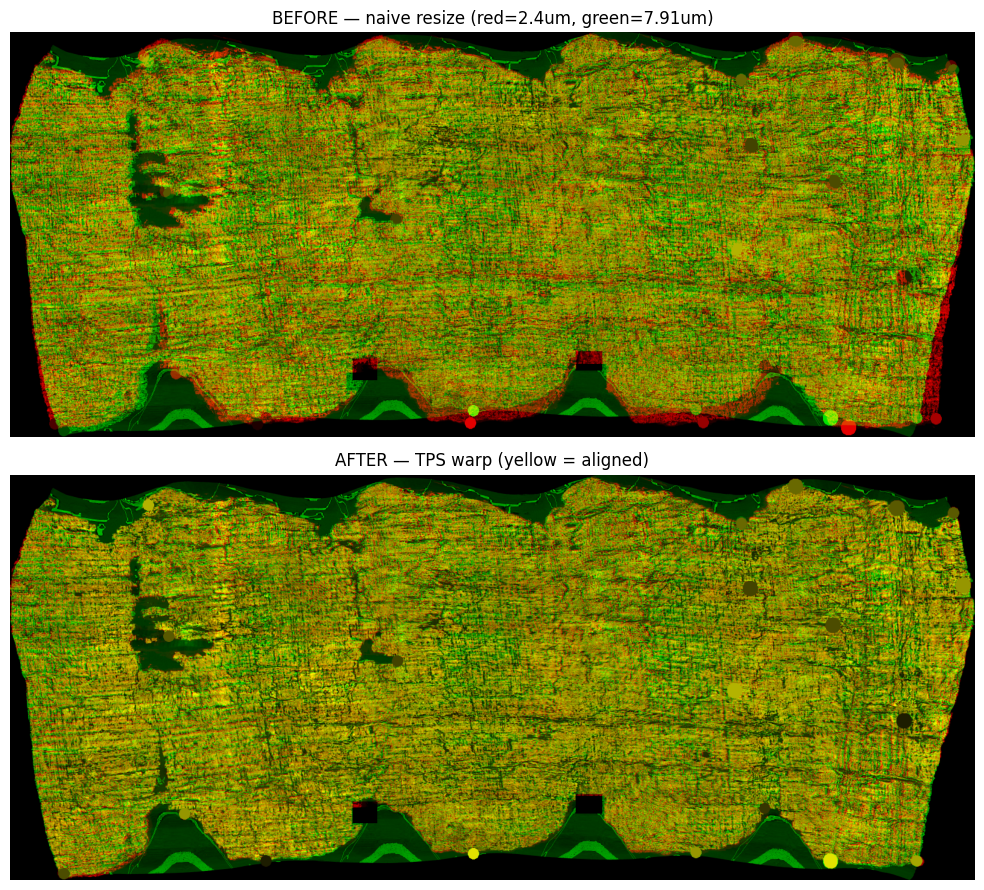

: 

In [ ]:
src_gray = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2GRAY)
dst_gray = cv2.cvtColor(dst_bgr, cv2.COLOR_BGR2GRAY)

# BEFORE: naive resize of source onto target frame (no geometric correction)
src_naive = cv2.resize(src_gray, (dw, dh))
before = np.dstack([src_naive, dst_gray, np.zeros_like(dst_gray)])

# AFTER: TPS-warped source sampled into the target frame
src_warp = cv2.remap(src_gray, mapx, mapy, cv2.INTER_LINEAR, borderValue=0)
after = np.dstack([src_warp, dst_gray, np.zeros_like(dst_gray)])

fig, ax = plt.subplots(2, 1, figsize=(16, 9))
ax[0].imshow(before); ax[0].set_title('BEFORE — naive resize (red=2.4um, green=7.91um)'); ax[0].axis('off')
ax[1].imshow(after);  ax[1].set_title('AFTER — TPS warp (yellow = aligned)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## Takeaways

- The warp is a purely **2D in-plane** map (`mapx`, `mapy`). The real tool builds it at a higher
  working width and applies the *same* map to the 2.4um **ink labels** (`cv2.remap` with nearest
  interpolation) to drop them into the 7.91um frame — see `warp_from_dots.py` and
  `bake_scroll4_79_labels.py`.
- More corresponding dots → tighter alignment, especially away from the scallop humps. 12 colors
  is the practical ceiling for pure color-based auto-matching.
- This aligns the sheets **in-plane only**; it does not (and cannot) register depth, and it does
  not add ink signal to the 7.91um data — its job is label transfer, nothing more.